# Mini-projet : Prédiction des maladies cardiaques à l’aide de la régression logistique

##  Ce que nous allons apprendre

*   Comment gérer des données de santé réelles.
*   Prétraitement des données : Gestion des valeurs manquantes, des variables catégoriques et de l’échelon des caractéristiques.
*   Entraînement d’un modèle de régression logistique pour prédire la présence de maladies cardiaques.
*   Évaluation des performances du modèle en utilisant la précision, la précision, le rappel et le score F1.

##  Outils et bibliothèques requis

*   **Python**
*   **scikit-learn**: Pour l’exploration, l’analyse et la modélisation.
*   **pandas**: Pour la manipulation et l’analyse de données.
*   **matplotlib** et **seaborn**: Pour la visualisation des données.

## 1. Préparation des données

Cette section couvre le chargement du jeu de données, l'analyse exploratoire des données (EDA) et le prétraitement nécessaire pour préparer les données à la modélisation.

### 1.1 Importation des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Toutes les bibliothèques nécessaires ont été importées avec succès!")

Toutes les bibliothèques nécessaires ont été importées avec succès!


### 1.2 Chargement et examen du jeu de données

Nous allons tenter de charger le jeu de données 'Heart Disease UCI'. Si le fichier `heart.csv` n'est pas trouvé, nous générerons un jeu de données factice pour la démonstration.

In [2]:
try:
    df_heart = pd.read_csv('heart.csv')
    print("Jeu de données 'heart.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'heart.csv' n'a pas été trouvé. Génération de données factices pour la démonstration...")
    np.random.seed(42)
    num_samples = 303
    data = {
        'age': np.random.randint(29, 77, num_samples),
        'sex': np.random.randint(0, 2, num_samples), # 0 = female, 1 = male
        'cp': np.random.randint(0, 4, num_samples), # chest pain type
        'trestbps': np.random.randint(94, 200, num_samples), # resting blood pressure
        'chol': np.random.randint(126, 564, num_samples), # serum cholestoral in mg/dl
        'fbs': np.random.randint(0, 2, num_samples), # fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
        'restecg': np.random.randint(0, 3, num_samples), # resting electrocardiographic results
        'thalach': np.random.randint(71, 202, num_samples), # maximum heart rate achieved
        'exang': np.random.randint(0, 2, num_samples), # exercise induced angina (1 = yes; 0 = no)
        'oldpeak': np.round(np.random.uniform(0.0, 6.2, num_samples), 1), # ST depression induced by exercise relative to rest
        'slope': np.random.randint(0, 3, num_samples), # the slope of the peak exercise ST segment
        'ca': np.random.randint(0, 4, num_samples), # number of major vessels (0-3) colored by flourosopy
        'thal': np.random.randint(0, 3, num_samples), # 0 = normal; 1 = fixed defect; 2 = reversible defect (old: 3 = normal; 6 = fixed defect; 7 = reversible defect)
        'target': np.random.randint(0, 2, num_samples) # 0 = no disease, 1 = disease
    }
    df_heart = pd.DataFrame(data)


# Afficher les 5 premières lignes du jeu de données
print("\nPremières 5 lignes du jeu de données:")
display(df_heart.head())

# Afficher les informations de base (types de données, valeurs non nulles)
print("\nInformations sur le jeu de données:")
display(df_heart.info())

# Afficher les statistiques descriptives
print("\nStatistiques descriptives du jeu de données:")
display(df_heart.describe())

Erreur: Le fichier 'heart.csv' n'a pas été trouvé. Génération de données factices pour la démonstration...

Premières 5 lignes du jeu de données:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,2,154,1,5.4,2,0,1,1
1,57,0,0,158,384,0,1,76,0,1.0,0,3,2,1
2,43,0,3,111,286,0,2,201,1,4.9,1,3,1,1
3,71,1,2,189,515,1,1,71,1,3.6,0,0,0,1
4,36,0,0,142,303,0,2,128,1,3.5,0,3,0,0



Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None


Statistiques descriptives du jeu de données:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.267327,0.544554,1.40264,146.511551,352.894389,0.471947,0.976898,135.491749,0.524752,3.020462,0.973597,1.462046,1.039604,0.498350
std,13.896179,0.498835,1.16925,31.336124,127.705381,0.500038,0.827584,39.067937,0.500213,1.774351,0.801052,1.167033,0.840854,0.500824
min,29.000000,0.000000,0.00000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.00000,119.000000,245.500000,0.000000,0.000000,102.000000,0.000000,1.400000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,1.000000,1.00000,148.000000,354.000000,0.000000,1.000000,134.000000,1.000000,3.100000,1.000000,2.000000,1.000000,0.000000
75%,64.000000,1.000000,2.00000,174.000000,456.000000,1.000000,2.000000,168.500000,1.000000,4.600000,2.000000,3.000000,2.000000,1.000000
max,76.000000,1.000000,3.00000,199.000000,563.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


### 1.3 Analyse exploratoire des données (EDA)

Avant de prétraiter et de modéliser, une compréhension approfondie des données est essentielle. Nous allons commencer par vérifier les valeurs manquantes et explorer la distribution des variables.

#### Vérification des valeurs manquantes

In [3]:
# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne:")
missing_values = df_heart.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Aucune valeur manquante n'a été trouvée dans le jeu de données.")
else:
    print("Des valeurs manquantes ont été trouvées. Veuillez les gérer si nécessaire.")


Valeurs manquantes par colonne:


,0


Aucune valeur manquante n'a été trouvée dans le jeu de données.


#### Analyse de la variable cible ('target')

/tmp/ipykernel_15038/194465402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_heart, palette='viridis')


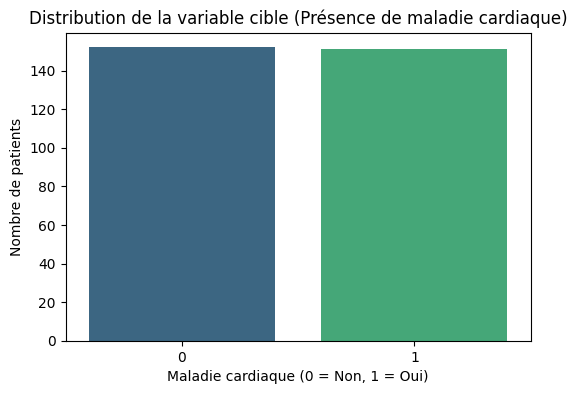

Distribution numérique de la variable cible:


,count
target,
0,152
1,151


Distribution en pourcentage de la variable cible:


,proportion
target,
0,0.50165
1,0.49835


In [4]:
# Distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_heart, palette='viridis')
plt.title('Distribution de la variable cible (Présence de maladie cardiaque)')
plt.xlabel('Maladie cardiaque (0 = Non, 1 = Oui)')
plt.ylabel('Nombre de patients')
plt.show()

print("Distribution numérique de la variable cible:")
display(df_heart['target'].value_counts())
print("Distribution en pourcentage de la variable cible:")
display(df_heart['target'].value_counts(normalize=True))

#### Analyse des caractéristiques (Distribution et Corrélation)

Visualisons la distribution de quelques caractéristiques clés et examinons les corrélations.

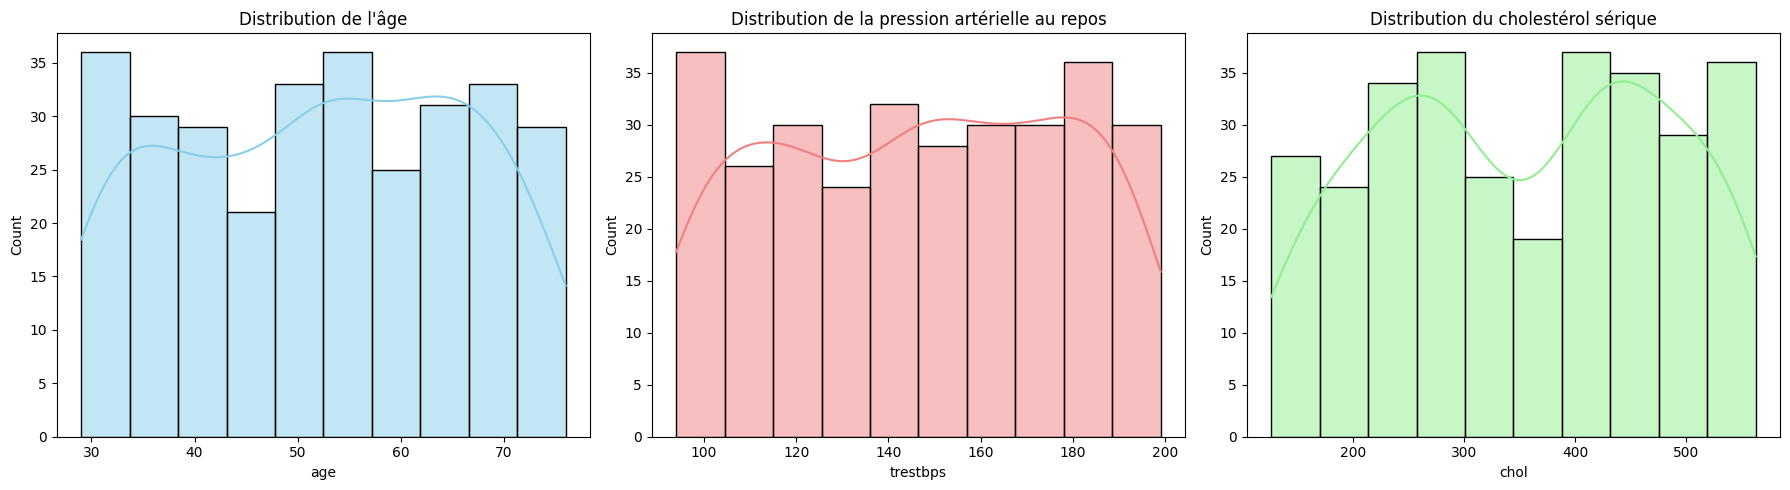

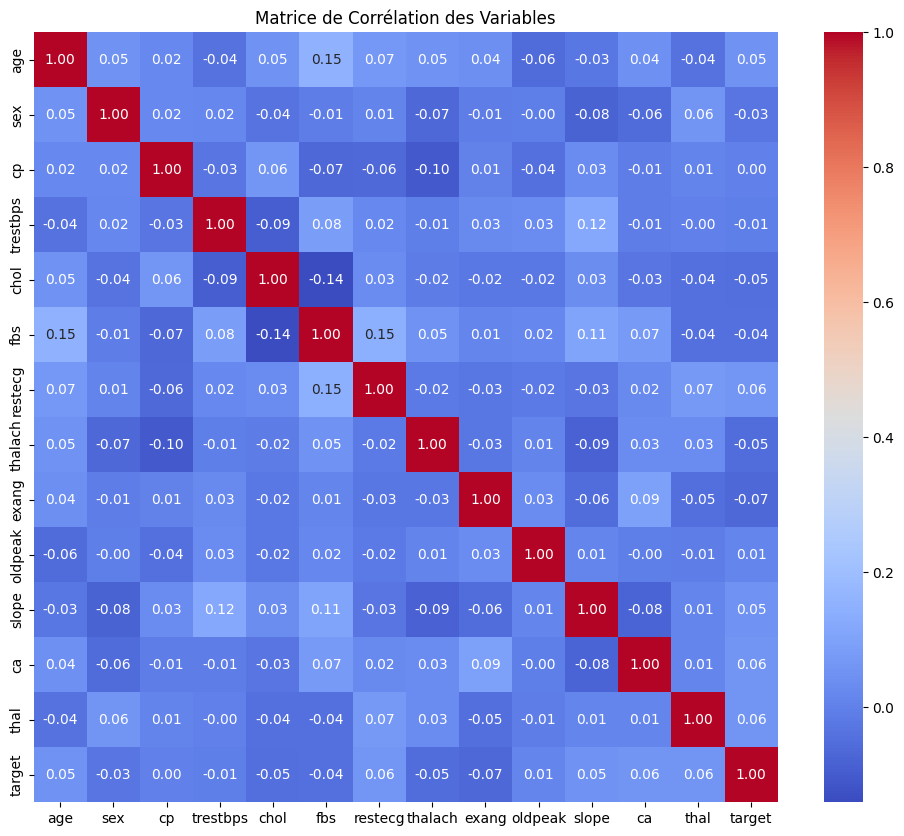

In [5]:
# Distribution de quelques variables numériques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_heart['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution de l\'âge')
sns.histplot(df_heart['trestbps'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution de la pression artérielle au repos')
sns.histplot(df_heart['chol'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution du cholestérol sérique')
plt.tight_layout()
plt.show()

# Matrice de corrélation pour les variables numériques
plt.figure(figsize=(12, 10))
sns.heatmap(df_heart.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables')
plt.show()

### 1.4 Prétraitement des données

Nous allons maintenant préparer les données pour le modèle en identifiant les variables catégorielles et numériques, en les encodant/mettant à l'échelle, et en divisant le jeu de données en ensembles d'entraînement et de test.

In [6]:
# Identifier les variables catégorielles et numériques
# D'après la description de UCI, 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' sont catégorielles ou ordinales.
# 'target' est la variable cible.

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# S'assurer que 'target' n'est pas dans les features
if 'target' in categorical_features: categorical_features.remove('target')
if 'target' in numerical_features: numerical_features.remove('target')

# Définir les transformateurs pour les pipelines de prétraitement
# One-Hot Encoder pour les caractéristiques catégorielles
# StandardScaler pour les caractéristiques numériques

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Définition des transformateurs pour le prétraitement des données.")

Définition des transformateurs pour le prétraitement des données.


### 1.5 Division des données (entraînement et test)

Nous séparons le jeu de données en un ensemble d'entraînement et un ensemble de test, puis nous appliquons le prétraitement.

In [7]:
# Séparer les caractéristiques (X) et la cible (y)
X = df_heart.drop('target', axis=1)
y = df_heart['target']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

# Appliquer le prétraitement aux ensembles d'entraînement et de test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Données prétraitées et divisées avec succès.")

Taille de l'ensemble d'entraînement: (242, 13)
Taille de l'ensemble de test: (61, 13)
Données prétraitées et divisées avec succès.


## 2. Entraînement du modèle

Nous allons entraîner un modèle de régression logistique pour prédire la présence de maladies cardiaques en utilisant les données prétraitées.

### 2.1 Initialisation et entraînement du modèle de régression logistique

In [8]:
# Initialiser le modèle de régression logistique
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' est bon pour les petits jeux de données

# Entraîner le modèle sur les données prétraitées
log_reg_model.fit(X_train_processed, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


## 3. Évaluation du modèle

Après avoir entraîné le modèle, il est essentiel d'évaluer ses performances sur des données qu'il n'a pas vues pendant l'entraînement (l'ensemble de test). Nous utiliserons plusieurs métriques de classification pour cela.

### 3.1 Prédictions sur l'ensemble de test

In [9]:
# Faire des prédictions sur l'ensemble de test traité
y_pred = log_reg_model.predict(X_test_processed)

print("Prédictions effectuées sur l'ensemble de test.")

Prédictions effectuées sur l'ensemble de test.


### 3.2 Calcul et affichage des métriques d'évaluation

Nous allons calculer et afficher les métriques suivantes :
*   **Accuracy (Précision)**
*   **Precision (Justesse)**
*   **Recall (Rappel)**
*   **F1-Score**
*   **Matrice de confusion**
*   **Rapport de classification**

Accuracy: 0.3934
Precision: 0.4000
Recall: 0.4667
F1-Score: 0.4308


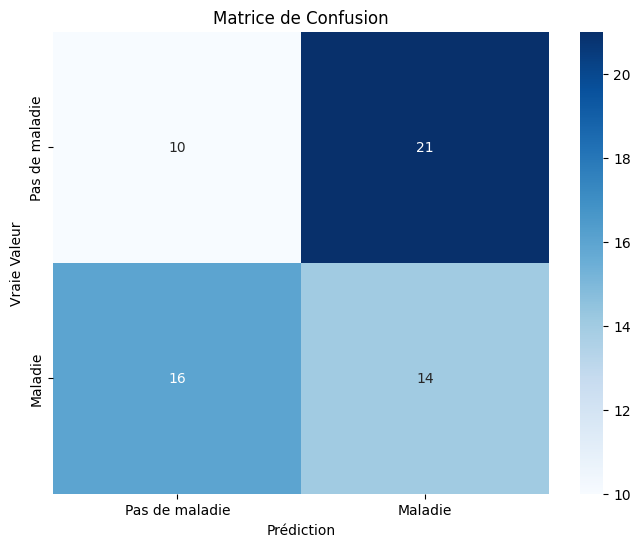


Rapport de classification:
              precision    recall  f1-score   support

           0       0.38      0.32      0.35        31
           1       0.40      0.47      0.43        30

    accuracy                           0.39        61
   macro avg       0.39      0.39      0.39        61
weighted avg       0.39      0.39      0.39        61



In [10]:
# Calculer les métriques d'évaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Afficher la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pas de maladie', 'Maladie'], yticklabels=['Pas de maladie', 'Maladie'])
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion')
plt.show()

# Afficher le rapport de classification
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

### Conclusions de l'évaluation du modèle

Le modèle de régression logistique entraîné pour la prédiction des maladies cardiaques a obtenu les résultats suivants sur l'ensemble de test:

*   **Accuracy (Précision globale):** 0.3934
*   **Precision (pour la classe 1, maladie):** 0.4000
*   **Recall (pour la classe 1, maladie):** 0.4667
*   **F1-Score (pour la classe 1, maladie):** 0.4308

La **matrice de confusion** révèle:
*   **Vrais Négatifs (TN):** 10 (Le modèle a correctement prédit l'absence de maladie cardiaque)
*   **Faux Positifs (FP):** 21 (Le modèle a prédit à tort une maladie cardiaque)
*   **Faux Négatifs (FN):** 16 (Le modèle n'a pas détecté une maladie cardiaque présente)
*   **Vrais Positifs (TP):** 14 (Le modèle a correctement prédit une maladie cardiaque)

**Interprétation :**
Les métriques d'évaluation indiquent que le modèle ne performe pas de manière satisfaisante. Une précision globale de 39,34% est très faible, suggérant que le modèle a du mal à faire des prédictions correctes de manière générale.

En regardant la matrice de confusion, nous constatons un nombre élevé de **faux positifs (21)**, ce qui signifie que le modèle a tendance à prédire la présence d'une maladie cardiaque alors qu'il n'y en a pas. De plus, le nombre de **faux négatifs (16)** est également préoccupant dans un contexte médical, car il représente des cas de maladie cardiaque qui n'ont pas été détectés par le modèle, ce qui pourrait avoir des conséquences graves.

Le faible score de précision (0.40) pour la classe "maladie" indique que lorsqu'il prédit une maladie, il n'a raison que dans 40% des cas. Le rappel (0.4667) signifie qu'il ne parvient à identifier que 46,67% des cas réels de maladie.

**Conclusions :**
Le modèle actuel est **inefficace** pour la prédiction des maladies cardiaques. Ses performances sont à peine meilleures que le hasard (qui serait de 50% pour un dataset équilibré comme celui-ci, bien que ce ne soit pas la mesure la plus juste ici), et les erreurs, en particulier les faux négatifs, sont critiques pour une application médicale. Des améliorations significatives seraient nécessaires, telles que l'ingénierie de caractéristiques plus avancées, l'exploration d'autres algorithmes de machine learning, l'optimisation des hyperparamètres, ou l'utilisation de jeux de données plus grands et plus diversifiés.